# Decimation Sweep — Results Analysis

Analyse the CSV produced by the no-bandpass decimation sweep
(`configs/frequency_decoding_sweep_no_bandpass_decimate.yaml`).

- **Section 1** — Data loading & setting labels
- **Section 2** — Above-chance detection per session and setting
- **Section 3** — Cross-setting comparison (box-and-whisker plot)
- **Section 4** — Paired statistical tests between settings

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from pathlib import Path
from scipy.stats import wilcoxon

plt.style.use('academic.mplstyle')

OSError: 'academic.mplstyle' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## 1  Data Loading & Setting Labels

In [ ]:
CSV_PATH = Path("/home/mila/s/sobralm/auditorydecoding/results/decimate_sweep_3.csv")
df = pd.read_csv(CSV_PATH)

METRIC = "balanced_accuracy"
ALPHA = 0.05

print(f"Total rows:  {len(df)}")
print(f"Recordings:  {df['recording_id'].nunique()}")
df.head()

Total rows:  702
Recordings:  39


,run_name,recording_id,lowcut,highcut,stft,decimate_factor,accuracy,balanced_accuracy,f1_macro,cohen_kappa,perm_pvalue,perm_zscore,n_classes,n_valid_samples,elapsed_seconds
0,lonone_hinone_stft_dec75,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,NaN,NaN,True,75,0.233918,0.188115,0.178136,0.070652,0.0410,1.784160,7,171,37.58
1,lonone_hinone_stft_dec30,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,NaN,NaN,True,30,0.269006,0.251261,0.254698,0.124836,0.0000,4.172843,7,171,37.90
2,lonone_hinone_stft_dec50,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,NaN,NaN,True,50,0.233918,0.205162,0.202192,0.085225,0.0126,2.346614,7,171,37.95
3,lonone_hinone_raw_dec50,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,NaN,NaN,False,50,0.245614,0.187395,0.169822,0.079955,0.0427,1.847708,7,171,37.97
4,lonone_hinone_stft_dec20,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,NaN,NaN,True,20,0.233918,0.205282,0.203064,0.084702,0.0091,2.389515,7,171,38.03


In [ ]:
def setting_label(row: pd.Series) -> str:
    feat = "STFT" if row["stft"] else "Raw"
    dec = int(row["decimate_factor"])
    resample = f"dec{dec}" if dec > 1 else "nodec"
    return f"{feat}, {resample}"

df["setting"] = df.apply(setting_label, axis=1)

eegnet_dir = Path("/home/mila/s/sobralm/Foundry/runs/EEGNET_NEUROSOFT_ALL_SESSIONS")
eegnet_frames = []
for session_dir in sorted(eegnet_dir.iterdir()):
    csv_path = session_dir / "results.csv"
    if csv_path.exists():
        eegnet_frames.append(pd.read_csv(csv_path))
df_eegnet = pd.concat(eegnet_frames, ignore_index=True)
df_eegnet["setting"] = "EEGNet"
df = pd.concat([df, df_eegnet], ignore_index=True)

# Keep subject coloring consistent across all figures.
df["subject_id"] = (
    df["recording_id"]
    .str.extract(r"(sub-[^_]+)", expand=False)
    .fillna("unknown")
)
SUBJECT_ORDER = sorted(df["subject_id"].unique())
SUBJECT_COLORS = dict(
    zip(SUBJECT_ORDER, sns.color_palette("husl", n_colors=len(SUBJECT_ORDER)))
)

SETTING_ORDER = [
    "Raw, nodec",
    "Raw, dec5",
    "Raw, dec10",
    "Raw, dec20",
    "Raw, dec30",
    "Raw, dec40",
    "Raw, dec50",
    "Raw, dec75",
    "Raw, dec100",
    "STFT, nodec",
    "STFT, dec5",
    "STFT, dec10",
    "STFT, dec20",
    "STFT, dec30",
    "STFT, dec40",
    "STFT, dec50",
    "STFT, dec75",
    "STFT, dec100",
    "EEGNet",
]

PALETTE = {
    "Raw, nodec":   "#e8f4f8",
    "Raw, dec5":    "#c8e1ed",
    "Raw, dec10":   "#a8d0e6",
    "Raw, dec20":   "#88b8d8",
    "Raw, dec30":   "#6b9ac4",
    "Raw, dec40":   "#527ba8",
    "Raw, dec50":   "#3a6ea5",
    "Raw, dec75":   "#1f4d7a",
    "Raw, dec100":  "#003f5c",
    "STFT, nodec":  "#fce4ec",
    "STFT, dec5":   "#f8c9d9",
    "STFT, dec10":  "#f4a6c1",
    "STFT, dec20":  "#ee8aab",
    "STFT, dec30":  "#e8759b",
    "STFT, dec40":  "#de5f8d",
    "STFT, dec50":  "#d45087",
    "STFT, dec75":  "#b93d73",
    "STFT, dec100": "#a03060",
    "EEGNet":       "#6abf69",
}

print("Settings:", df["setting"].unique())
print(f"Total rows: {len(df)}")
print(f"EEGNet sessions: {len(df_eegnet)}")

Settings: <StringArray>
[ 'STFT, dec75',  'STFT, dec30',  'STFT, dec50',   'Raw, dec50',
  'STFT, dec20',   'Raw, dec20', 'STFT, dec100',   'Raw, dec30',
   'Raw, dec40',  'STFT, dec40',   'Raw, dec10',  'STFT, dec10',
    'Raw, dec5',   'STFT, dec5',   'Raw, nodec',  'STFT, nodec',
   'Raw, dec75',  'Raw, dec100',       'EEGNet']
Length: 19, dtype: str
Total rows: 741
EEGNet sessions: 39


## 2  Above-Chance Detection

A session/setting pair is **above chance** when the permutation
p-value < 0.05.

In [ ]:
df["above_chance"] = df["perm_pvalue"] < ALPHA

pivot_above = df.pivot_table(
    index="recording_id",
    columns="setting",
    values="above_chance",
    aggfunc="first",
)[SETTING_ORDER]

pivot_acc = df.pivot_table(
    index="recording_id",
    columns="setting",
    values=METRIC,
    aggfunc="first",
)[SETTING_ORDER]

n_above = pivot_above.sum()
n_total = len(pivot_above)

print("Sessions above chance (p < 0.05) per setting:")
for s in SETTING_ORDER:
    print(f"  {s:25s}  {int(n_above[s]):2d} / {n_total}")

Sessions above chance (p < 0.05) per setting:
  Raw, nodec                 36 / 39
  Raw, dec5                  36 / 39
  Raw, dec10                 36 / 39
  Raw, dec20                 36 / 39
  Raw, dec30                 35 / 39
  Raw, dec40                 36 / 39
  Raw, dec50                 38 / 39
  Raw, dec75                 36 / 39
  Raw, dec100                36 / 39
  STFT, nodec                35 / 39
  STFT, dec5                 38 / 39
  STFT, dec10                38 / 39
  STFT, dec20                36 / 39
  STFT, dec30                35 / 39
  STFT, dec40                36 / 39
  STFT, dec50                37 / 39
  STFT, dec75                31 / 39
  STFT, dec100               36 / 39
  EEGNet                     39 / 39


In [ ]:
ABOVE_STYLE = "background-color: #dceef7; color: #003f5c"
BELOW_STYLE = "background-color: #f5dde5; color: #a03060"

styled = pivot_acc.style.apply(
    lambda col: [
        ABOVE_STYLE if pivot_above.loc[idx, col.name] else BELOW_STYLE
        for idx in col.index
    ],
    axis=0,
).format("{:.4f}")

styled

setting,"Raw, nodec","Raw, dec5","Raw, dec10","Raw, dec20","Raw, dec30","Raw, dec40","Raw, dec50","Raw, dec75","Raw, dec100","STFT, nodec","STFT, dec5","STFT, dec10","STFT, dec20","STFT, dec30","STFT, dec40","STFT, dec50","STFT, dec75","STFT, dec100",EEGNet
recording_id,,,,,,,,,,,,,,,,,,,
sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,0.1720,0.1503,0.1421,0.1792,0.1627,0.1665,0.1874,0.1749,0.1623,0.3251,0.2096,0.2258,0.2053,0.2513,0.2094,0.2052,0.1881,0.2047,0.4382
sub-01_ses-02_task-AcousStim_acq-LH_desc-raw,0.0835,0.0850,0.0396,0.0401,0.0436,0.0525,0.0466,0.0441,0.0608,0.4035,0.1119,0.0923,0.0803,0.1046,0.1196,0.1131,0.0746,0.0990,0.2960
sub-02_ses-01_task-AcousStim_acq-LH_desc-raw,0.2946,0.3087,0.3133,0.2739,0.2712,0.2356,0.3056,0.3445,0.2478,0.3692,0.4140,0.3811,0.3954,0.3500,0.3569,0.3712,0.3561,0.2793,0.4441
sub-02_ses-01_task-AcousStim_acq-RH_desc-raw,0.2841,0.2825,0.2944,0.2714,0.2631,0.2441,0.2192,0.1928,0.2047,0.4392,0.4079,0.4101,0.3710,0.2976,0.3297,0.2844,0.2455,0.2547,0.4344
sub-02_ses-02_task-AcousStim_acq-LH_desc-raw,0.2384,0.2711,0.2649,0.2936,0.2837,0.2718,0.2837,0.2680,0.2801,0.2488,0.2378,0.2501,0.1634,0.1312,0.1749,0.1535,0.1266,0.1337,0.3243
sub-02_ses-02_task-AcousStim_acq-RH_desc-raw,0.1790,0.1619,0.1795,0.1829,0.1781,0.1843,0.1838,0.2203,0.1772,0.3586,0.2715,0.2623,0.2042,0.1890,0.1650,0.1833,0.1586,0.0768,0.3296
sub-03_ses-01_task-AcousStim_acq-LH_desc-raw,0.5249,0.5020,0.4623,0.4796,0.4831,0.5075,0.4874,0.4531,0.4820,0.4202,0.4184,0.4341,0.3829,0.3291,0.3340,0.3378,0.3128,0.3391,0.6657
sub-03_ses-01_task-AcousStim_acq-RH_desc-raw,0.4169,0.4130,0.4046,0.4154,0.4398,0.4420,0.4298,0.4629,0.4741,0.3624,0.4613,0.4719,0.3673,0.3547,0.3299,0.3574,0.2920,0.3028,0.4779
sub-03_ses-03_task-AcousStim_acq-LHanest_desc-raw,0.5052,0.5193,0.5245,0.5306,0.5339,0.5148,0.5119,0.4649,0.4244,0.2632,0.2908,0.2763,0.2616,0.2078,0.2053,0.2110,0.1835,0.2013,0.5599


## 3  Cross-Setting Comparison — Box-and-Whisker Plot

Each dot is one recording session. The dashed line marks the
median chance level across sessions (1 / n_classes).

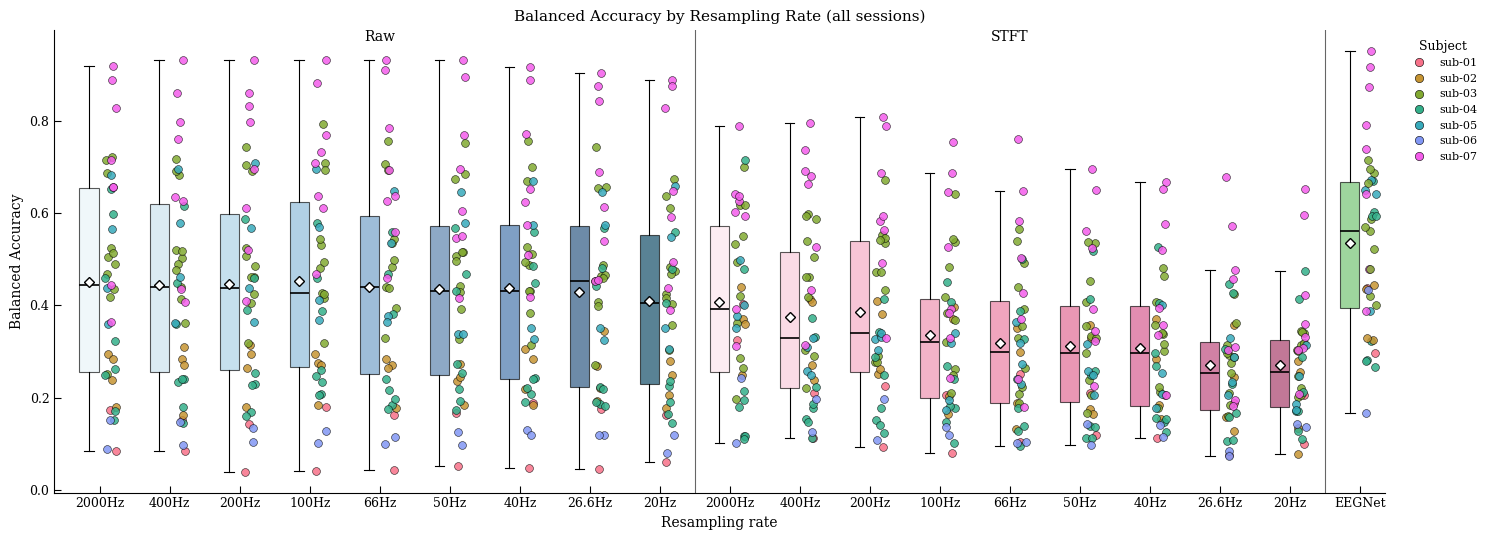

In [50]:
from matplotlib.lines import Line2D

setting_to_idx = {s: i for i, s in enumerate(SETTING_ORDER)}
BOX_OFFSET = -0.15
STRIP_OFFSET = 0.15

fig, ax = plt.subplots(figsize=(15, 5.5))

positions = [i + BOX_OFFSET for i in range(len(SETTING_ORDER))]
box_data = [df.loc[df["setting"] == s, METRIC].values for s in SETTING_ORDER]
bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.28,
    patch_artist=True,
    showfliers=False,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=0.8),
    capprops=dict(color="black", linewidth=0.8),
)
for patch, setting in zip(bp["boxes"], SETTING_ORDER):
    patch.set_facecolor(PALETTE[setting])
    patch.set_edgecolor("black")
    patch.set_linewidth(0.8)
    patch.set_alpha(0.65)

rng = np.random.default_rng(42)
for _, row in df.iterrows():
    xi = setting_to_idx[row["setting"]] + STRIP_OFFSET
    jitter = rng.uniform(-0.08, 0.08)
    y = row[METRIC]

    ax.scatter(
        xi + jitter,
        y,
        s=32,
        c=[SUBJECT_COLORS[row["subject_id"]]],
        edgecolors="black",
        linewidths=0.4,
        alpha=0.85,
        zorder=3,
    )

subject_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=SUBJECT_COLORS[subject],
        markeredgecolor="black",
        markeredgewidth=0.4,
        markersize=6,
        label=subject,
    )
    for subject in SUBJECT_ORDER
]


dec_labels = ["2000Hz", "400Hz", "200Hz", "100Hz", "66Hz", "50Hz", "40Hz", "26.6Hz", "20Hz", "2000Hz", "400Hz", "200Hz", "100Hz", "66Hz", "50Hz", "40Hz", "26.6Hz", "20Hz", "EEGNet"]
ax.set_xticks(range(len(SETTING_ORDER)))
ax.set_xticklabels(dec_labels)
ax.axvline(8.5, color="black", linewidth=0.8, alpha=0.6)
ax.axvline(17.5, color="black", linewidth=0.8, alpha=0.6)
ax.text(4.0, 1.0, "Raw", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=10)
ax.text(13.0, 1.0, "STFT", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=10)
# ax.text(18.0, 0.05, "EEGNet", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=10)

ax.set_xlabel("Resampling rate")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Balanced Accuracy by Resampling Rate (all sessions)")
ax.legend(
    handles=subject_handles,
    title="Subject",
    bbox_to_anchor=(1.01, 1.0),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=False,
)
sns.despine()

fig.subplots_adjust(bottom=0.26)
plt.tight_layout()
plt.show()
# Save the figure in high resolution
fig.savefig("decimate_balanced_accuracy_by_setting.png", dpi=300, bbox_inches="tight")

## 3b  No-Decimate Comparison — Raw vs STFT vs EEGNet

Simplified box-and-whisker comparing only the three baseline
(no decimation) approaches.

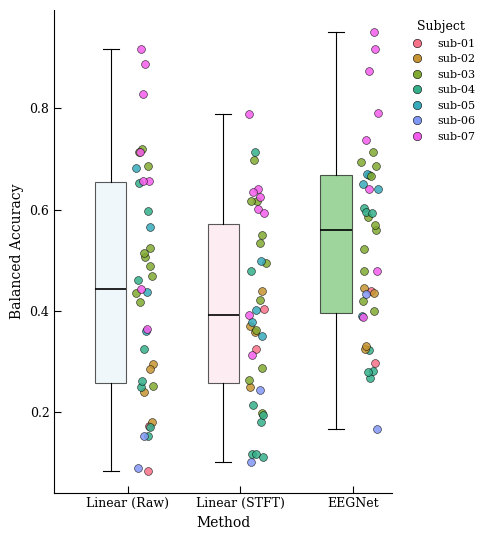

In [ ]:
from matplotlib.lines import Line2D

NODEC_ORDER = ["Raw, nodec", "STFT, nodec", "EEGNet"]
NODEC_LABELS = ["Linear (Raw)", "Linear (STFT)", "EEGNet"]

setting_to_idx_nd = {s: i for i, s in enumerate(NODEC_ORDER)}
BOX_OFFSET_ND = -0.15
STRIP_OFFSET_ND = 0.15

df_nodec = df[df["setting"].isin(NODEC_ORDER)]

fig, ax = plt.subplots(figsize=(5, 5.5))

positions_nd = [i + BOX_OFFSET_ND for i in range(len(NODEC_ORDER))]
box_data_nd = [df_nodec.loc[df_nodec["setting"] == s, METRIC].values for s in NODEC_ORDER]
bp = ax.boxplot(
    box_data_nd,
    positions=positions_nd,
    widths=0.28,
    patch_artist=True,
    showfliers=False,
    # showmeans=True,
    # meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=0.8),
    capprops=dict(color="black", linewidth=0.8),
)
for patch, setting in zip(bp["boxes"], NODEC_ORDER):
    patch.set_facecolor(PALETTE[setting])
    patch.set_edgecolor("black")
    patch.set_linewidth(0.8)
    patch.set_alpha(0.65)

rng = np.random.default_rng(42)
for _, row in df_nodec.iterrows():
    xi = setting_to_idx_nd[row["setting"]] + STRIP_OFFSET_ND
    jitter = rng.uniform(-0.08, 0.08)
    y = row[METRIC]

    ax.scatter(
        xi + jitter,
        y,
        s=32,
        c=[SUBJECT_COLORS[row["subject_id"]]],
        edgecolors="black",
        linewidths=0.4,
        alpha=0.85,
        zorder=3,
    )

subject_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=SUBJECT_COLORS[subject],
        markeredgecolor="black",
        markeredgewidth=0.4,
        markersize=6,
        label=subject,
    )
    for subject in SUBJECT_ORDER
]

nodec_pivot = (
    df_nodec.pivot_table(
        index="recording_id",
        columns="setting",
        values=METRIC,
        aggfunc="first",
    )[NODEC_ORDER]
)

ax.set_xticks(range(len(NODEC_ORDER)))
ax.set_xticklabels(NODEC_LABELS)
ax.set_xlabel("Method")
ax.set_ylabel("Balanced Accuracy")
# ax.set_title("Auditory Decoding Performance (Linear vs EEGNet)")
ax.legend(
    handles=subject_handles,
    title="Subject",
    bbox_to_anchor=(1.01, 1.0),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=False,
)
sns.despine()

fig.subplots_adjust(bottom=0.26)
plt.tight_layout()
plt.show()
fig.savefig("nodec_balanced_accuracy_comparison.png", dpi=300, bbox_inches="tight")

## 4  Paired Statistical Tests

Wilcoxon signed-rank test for every pair of settings,
matched by recording.

In [49]:
rows = []
for a, b in combinations(SETTING_ORDER, 2):
    vals_a = pivot_acc[a].values
    vals_b = pivot_acc[b].values
    diff = vals_b - vals_a
    stat, p = wilcoxon(diff)
    rows.append({
        "Setting A": a,
        "Setting B": b,
        "median(A)": f"{np.median(vals_a):.4f}",
        "median(B)": f"{np.median(vals_b):.4f}",
        "median(B-A)": f"{np.median(diff):+.4f}",
        "B wins": int((diff > 0).sum()),
        "A wins": int((diff < 0).sum()),
        "Ties": int((diff == 0).sum()),
        "Wilcoxon p": f"{p:.4g}",
    })

results_df = pd.DataFrame(rows)
results_df[:10]

,Setting A,Setting B,median(A),median(B),median(B-A),B wins,A wins,Ties,Wilcoxon p
0,"Raw, nodec","Raw, dec5",0.4428,0.4400,+0.0015,21,18,0,0.9505
1,"Raw, nodec","Raw, dec10",0.4428,0.4383,+0.0005,20,19,0,0.9285
2,"Raw, nodec","Raw, dec20",0.4428,0.4260,+0.0052,22,17,0,0.4027
3,"Raw, nodec","Raw, dec30",0.4428,0.4398,+0.0024,20,19,0,0.6046
4,"Raw, nodec","Raw, dec40",0.4428,0.4298,-0.0051,19,20,0,0.3872
5,"Raw, nodec","Raw, dec50",0.4428,0.4302,-0.0040,17,21,1,0.4909
6,"Raw, nodec","Raw, dec75",0.4428,0.4517,-0.0261,17,22,0,0.07738
7,"Raw, nodec","Raw, dec100",0.4428,0.4050,-0.0331,7,30,2,0.001212
8,"Raw, nodec","STFT, nodec",0.4428,0.3911,-0.0542,15,24,0,0.124
9,"Raw, nodec","STFT, dec5",0.4428,0.3290,-0.0381,14,25,0,0.008562
